# Level 2 — Visualization

**Datasets:**
- Population by region (2022 census, NBS — same real data as Level 1)
- Maize production by region — **illustrative**, modeled on documented regional patterns (Southern Highlands and Lake Zone are Tanzania's top maize belts; Arusha and Ruvuma have shown recent gains; Dar es Salaam and Zanzibar have minimal agricultural land). Precise official region-level tonnage isn't published in a verifiable form, so these numbers are for practice, not policy.

**What you'll practice:**
- Bar charts (vertical & horizontal)
- Merging two DataFrames
- Scatter plots for relationships between variables
- Histograms for distributions
- Subplots (multiple charts in one figure)
- Basic styling: titles, labels, rotation, color, figure size

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Rebuild the population dataset (from Level 1)

In [2]:
population_data = {
    "Region": [
        "Dar es Salaam", "Mwanza", "Tabora", "Morogoro", "Dodoma",
        "Arusha", "Geita", "Songwe", "Iringa", "Mjini Magharibi", "Njombe"
    ],
    "Zone": [
        "Coastal", "Lake", "Western", "Eastern", "Central",
        "Northern", "Lake", "Southern Highlands", "Southern Highlands", "Zanzibar", "Southern Highlands"
    ],
    "Population_2022": [
        5383728, 3699872, 3391679, 3197104, 3085625,
        2356255, 2977608, 1344687, 1192728, 893169, 889946
    ]
}

pop_df = pd.DataFrame(population_data)
pop_df

,Region,Zone,Population_2022
0,Dar es Salaam,Coastal,5383728
1,Mwanza,Lake,3699872
2,Tabora,Western,3391679
3,Morogoro,Eastern,3197104
4,Dodoma,Central,3085625
5,Arusha,Northern,2356255
6,Geita,Lake,2977608
7,Songwe,Southern Highlands,1344687
8,Iringa,Southern Highlands,1192728
9,Mjini Magharibi,Zanzibar,893169


## 2. Build the (illustrative) maize production dataset

Values in 1,000 metric tonnes per year. Modeled on known regional strength patterns, not exact published figures — flagged clearly since we're mixing it with real census data.

In [3]:
crop_data = {
    "Region": [
        "Dar es Salaam", "Mwanza", "Tabora", "Morogoro", "Dodoma",
        "Arusha", "Geita", "Songwe", "Iringa", "Mjini Magharibi", "Njombe"
    ],
    "Maize_production_1000t": [
        5, 620, 410, 580, 190,
        540, 560, 710, 690, 2, 650
    ]
}

crop_df = pd.DataFrame(crop_data)
crop_df

,Region,Maize_production_1000t
0,Dar es Salaam,5
1,Mwanza,620
2,Tabora,410
3,Morogoro,580
4,Dodoma,190
5,Arusha,540
6,Geita,560
7,Songwe,710
8,Iringa,690
9,Mjini Magharibi,2


## 3. Merge the two datasets

This is the real-world move: you almost never get one dataset with everything in it. You get separate tables and join them on a shared key — here, `Region`.

In [4]:
df = pd.merge(pop_df, crop_df, on="Region")
df

,Region,Zone,Population_2022,Maize_production_1000t
0,Dar es Salaam,Coastal,5383728,5
1,Mwanza,Lake,3699872,620
2,Tabora,Western,3391679,410
3,Morogoro,Eastern,3197104,580
4,Dodoma,Central,3085625,190
5,Arusha,Northern,2356255,540
6,Geita,Lake,2977608,560
7,Songwe,Southern Highlands,1344687,710
8,Iringa,Southern Highlands,1192728,690
9,Mjini Magharibi,Zanzibar,893169,2


## 4. Bar chart — population by region

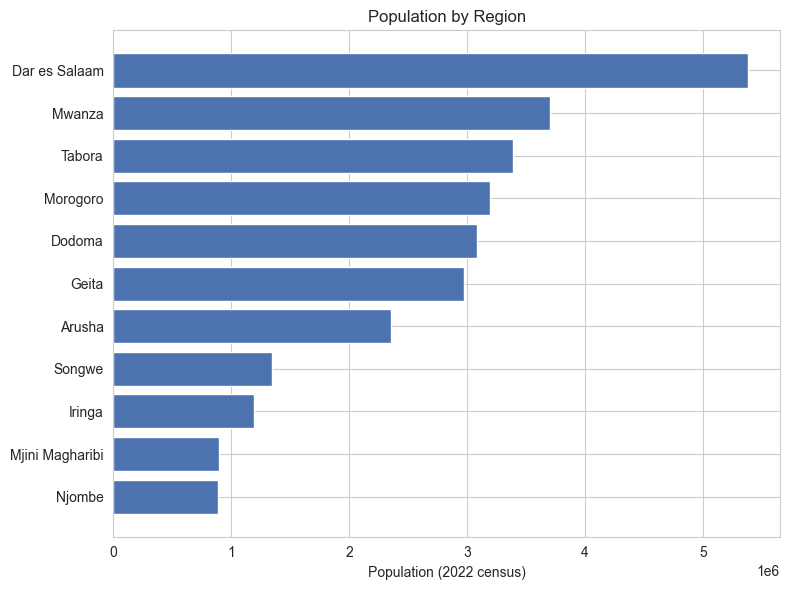

In [5]:
df_sorted = df.sort_values("Population_2022", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(df_sorted["Region"], df_sorted["Population_2022"], color="#4C72B0")
plt.xlabel("Population (2022 census)")
plt.title("Population by Region")
plt.tight_layout()
plt.show()

Horizontal bars (`barh`) instead of vertical — with long region names, vertical bars force rotated labels that are annoying to read. Horizontal is almost always the better call for category names longer than a couple of characters.

## 5. Scatter plot — population vs. maize production

Is there a relationship between how many people live in a region and how much maize it produces? A scatter plot is the fastest way to eyeball that.

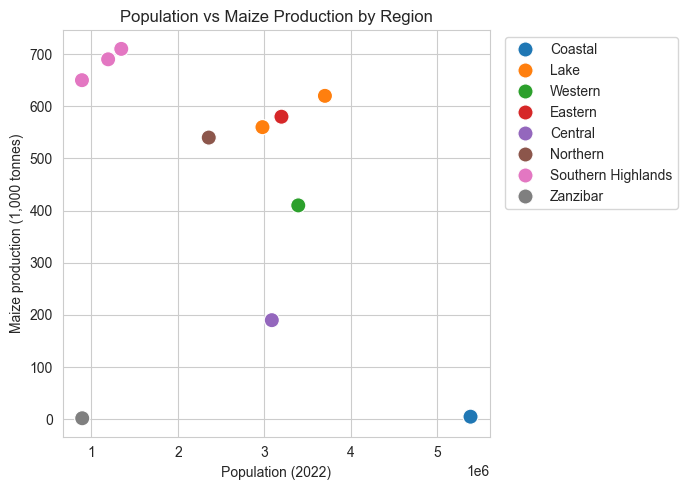

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Population_2022", y="Maize_production_1000t", hue="Zone", s=120)
plt.xlabel("Population (2022)")
plt.ylabel("Maize production (1,000 tonnes)")
plt.title("Population vs Maize Production by Region")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Notice Dar es Salaam and Mjini Magharibi sit far to the right (high population) but near the bottom (low maize output) — dense urban regions, not agricultural ones. That's the story a scatter plot tells at a glance that a table wouldn't.

## 6. Histogram — distribution of population values

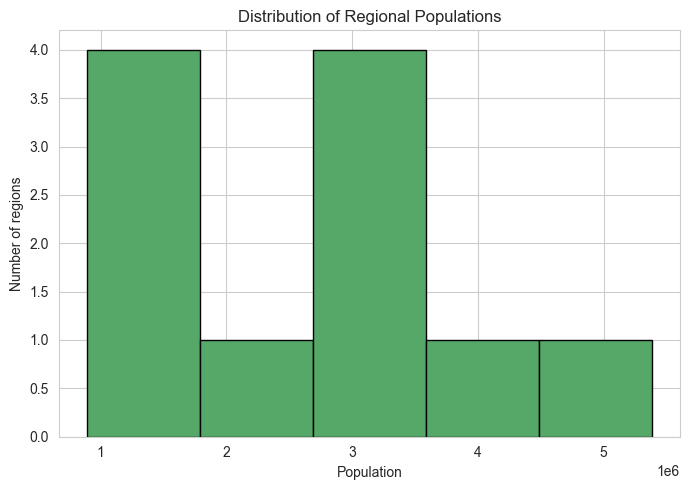

In [7]:
plt.figure(figsize=(7, 5))
plt.hist(df["Population_2022"], bins=5, color="#55A868", edgecolor="black")
plt.xlabel("Population")
plt.ylabel("Number of regions")
plt.title("Distribution of Regional Populations")
plt.tight_layout()
plt.show()

With only 11 regions this histogram is a bit coarse — worth remembering: histograms need a reasonable sample size to say much. This one mostly demonstrates the syntax; it'll be more useful in Level 3 with a bigger dataset.

## 7. Subplots — combine multiple charts in one figure

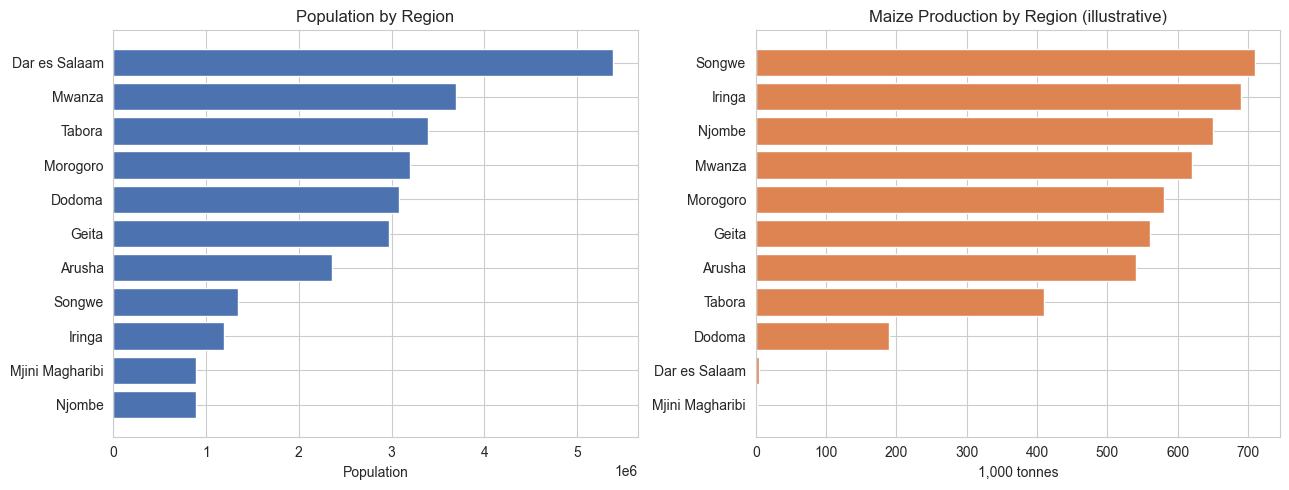

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_sorted_pop = df.sort_values("Population_2022")
axes[0].barh(df_sorted_pop["Region"], df_sorted_pop["Population_2022"], color="#4C72B0")
axes[0].set_title("Population by Region")
axes[0].set_xlabel("Population")

df_sorted_maize = df.sort_values("Maize_production_1000t")
axes[1].barh(df_sorted_maize["Region"], df_sorted_maize["Maize_production_1000t"], color="#DD8452")
axes[1].set_title("Maize Production by Region (illustrative)")
axes[1].set_xlabel("1,000 tonnes")

plt.tight_layout()
plt.show()

`plt.subplots(1, 2, ...)` gives you a 1-row, 2-column grid of axes. `axes[0]` and `axes[1]` are separate chart areas you plot into independently, then `tight_layout()` cleans up spacing so titles/labels don't overlap.

## Exercises

1. Make a bar chart of maize production grouped by `Zone` (hint: `groupby` first, then plot the result).
2. Change the scatter plot to size the points by `Maize_production_1000t` instead of just color by zone (hint: `size=` parameter in `sns.scatterplot`).
3. Create a 2x1 subplot grid (2 rows, 1 column) showing the population bar chart on top and the scatter plot on the bottom.
4. (Challenge) Add a `Population_millions` column, then create a bar chart where bar color intensity reflects a third variable — try `sns.barplot` with a `palette` argument.

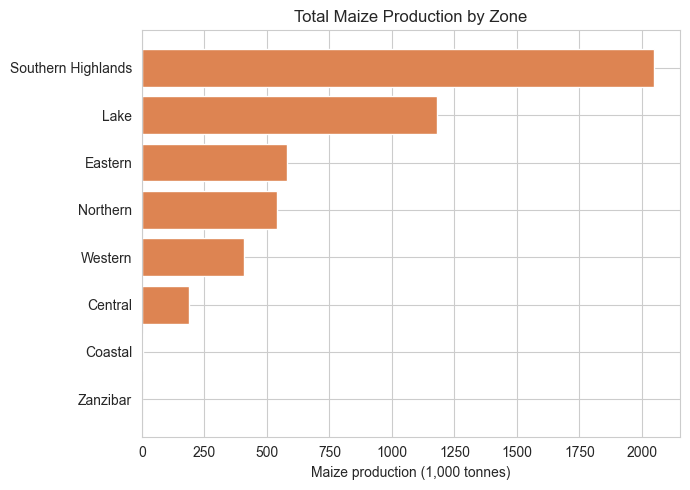

In [10]:
zone_maize = df.groupby("Zone")["Maize_production_1000t"].sum().sort_values()

plt.figure(figsize=(7, 5))
plt.barh(zone_maize.index, zone_maize.values, color="#DD8452")
plt.xlabel("Maize production (1,000 tonnes)")
plt.title("Total Maize Production by Zone")
plt.tight_layout()
plt.show()


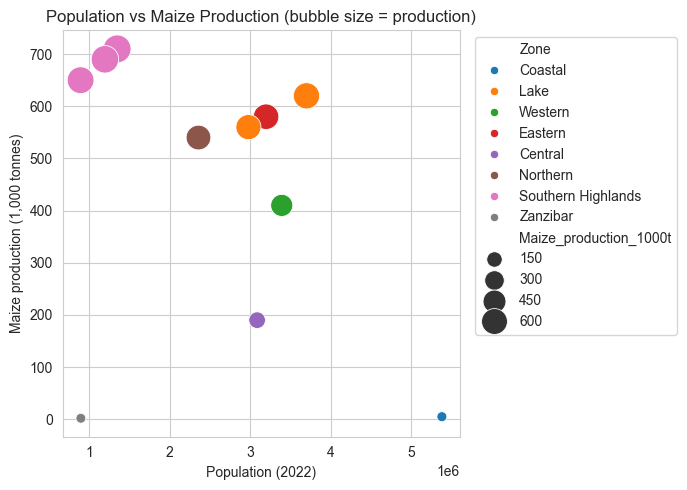

In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Population_2022",
    y="Maize_production_1000t",
    hue="Zone",
    size="Maize_production_1000t",
    sizes=(50, 400)
)
plt.xlabel("Population (2022)")
plt.ylabel("Maize production (1,000 tonnes)")
plt.title("Population vs Maize Production (bubble size = production)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

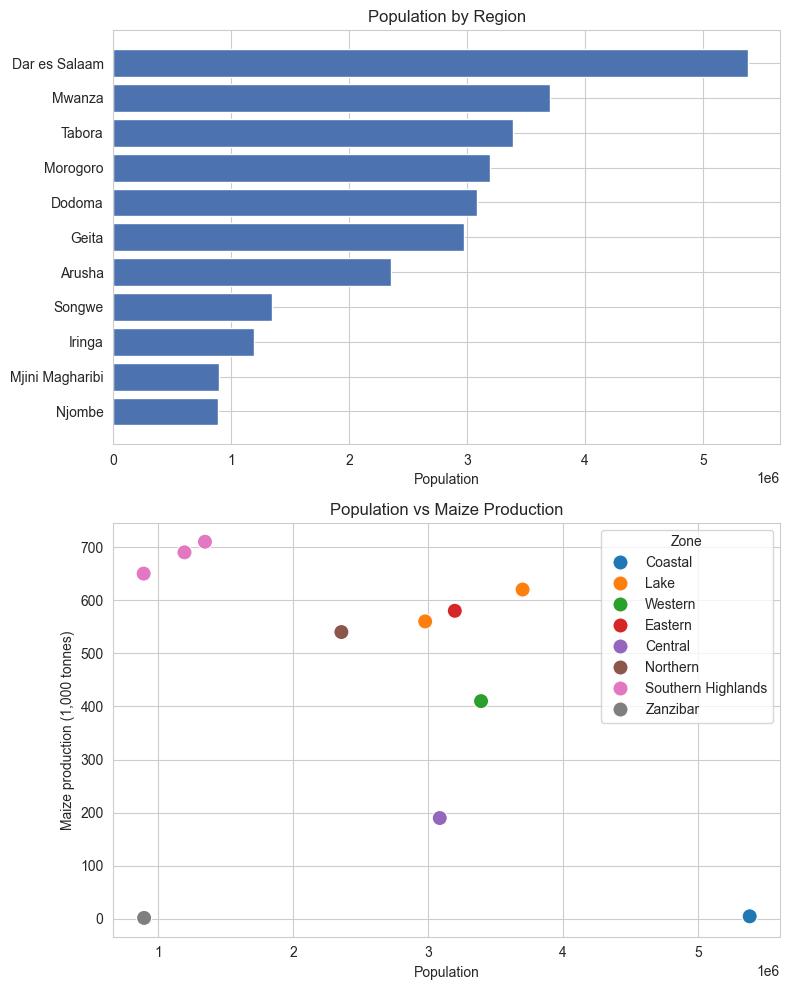

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

df_sorted_pop = df.sort_values("Population_2022")
axes[0].barh(df_sorted_pop["Region"], df_sorted_pop["Population_2022"], color="#4C72B0")
axes[0].set_title("Population by Region")
axes[0].set_xlabel("Population")

sns.scatterplot(data=df, x="Population_2022", y="Maize_production_1000t", hue="Zone", s=120, ax=axes[1])
axes[1].set_title("Population vs Maize Production")
axes[1].set_xlabel("Population")
axes[1].set_ylabel("Maize production (1,000 tonnes)")

plt.tight_layout()
plt.show()

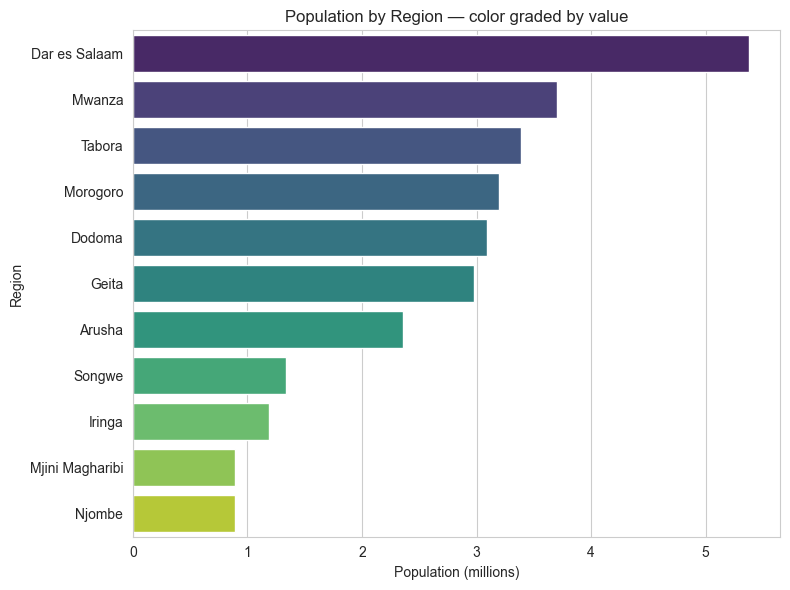

In [13]:
df["Population_millions"] = (df["Population_2022"] / 1_000_000).round(2)

df_sorted = df.sort_values("Population_millions", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_sorted,
    y="Region",
    x="Population_millions",
    hue="Region",
    palette="viridis",
    legend=False
)
plt.xlabel("Population (millions)")
plt.title("Population by Region — color graded by value")
plt.tight_layout()
plt.show()